In [28]:
import numpy as np
import matplotlib.pyplot as plt
import yastn
from yastn.tn import mps

import os
import glob

from scripts_fermions.operators import project_Ln, L_to_t
from sklearn.decomposition import PCA


from scipy.special import jv, gammaincc, gamma
from scipy.optimize import minimize

In [31]:
N, a, x0, sg2 = 256, 0.125, 3.0, 0.25
fname = f"./Proj_v=1_{N=}_{a=:0.4f}.npy"
PRs = np.load(fname, allow_pickle=True).item()

ts = np.linspace(0, N * a / 2, 9)
LLs = np.array([-2, -3/2, -1, -1/2, 0, 1/2, 1, 3/2, 2, 55])

Nas = [(256, 0.125)] # [(256, 0.125), (512, 0.0625), (512, 0.125)]
ms = [0.0, 0.5]
g = 1
Ds = [256, 512]


In [32]:
def get_probability(m, D):
    pls_mid = np.zeros((len(ts), len(LLs)))
    for i, t in enumerate(ts):
        for j, x in enumerate(PRs[m, D, t]):
           pls_mid[i, j] = x['pr']
    return pls_mid

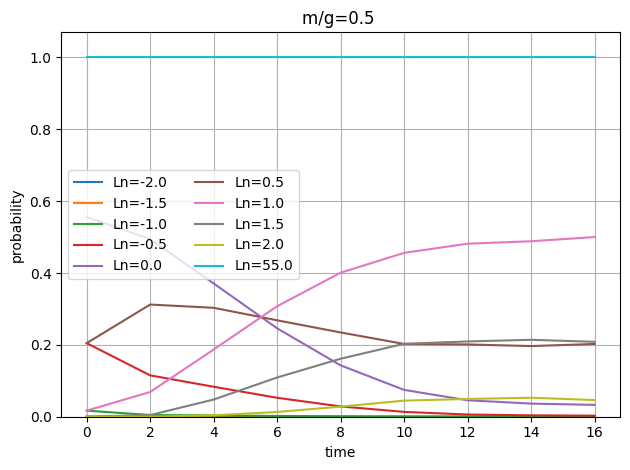

In [34]:
cm = plt.cm.jet
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]


D = 256
m = 0.5
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]

pls_mid = get_probability(m, D)
for kk, l in enumerate(LLs):
    plt.plot(ts[slc], pls_mid[slc, kk], label=f'Ln={l}')

plt.legend(ncols=2)
plt.ylim(0, 1.07)
plt.grid()
plt.xlabel('time')
plt.ylabel('probability')
plt.title(f"{m/g=} ")
#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")
plt.tight_layout()


Text(0, 0.5, 'Dominant PCA weight')

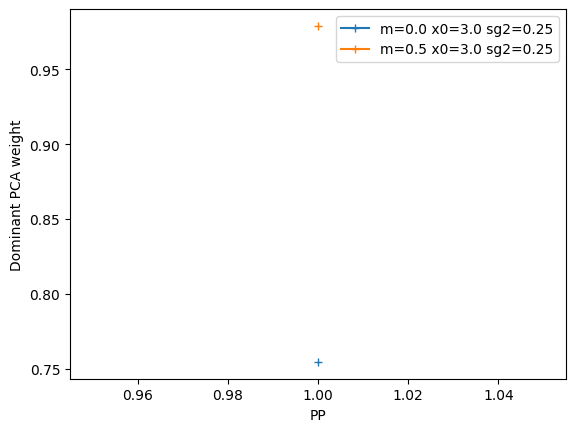

In [36]:
pca = PCA()

for m in ms:

    dom = []

    pls_mid = get_probability(m, D)
    pca.fit(pls_mid[slc])
    y = pca.explained_variance_ratio_[0]
    dom.append(y)
    plt.plot([1], dom, '-+', label=f"{m=} {x0=} {sg2=}")
plt.legend()
plt.xlabel("PP")
plt.ylabel("Dominant PCA weight")

In [37]:
def dominant_component(ax, m,  D):
    pls_mid = get_probability(m, D)
    pcaproj = PCA(n_components=1)
    pcaproj.fit(pls_mid[slc])
    pcacomp = pcaproj.transform(pls_mid[slc])


    def f(b, al, tau):
        return gammaincc(1+al, b*tau**2)

    y = pcacomp[:, 0]
    t = ts[slc]

    def mse(pars):
        c, b, a = pars
        return np.mean((y + a - c * f(b, 0, t)) ** 2)

    x0 = (0.57, 0.06, 0.1)
    sol = minimize(mse, x0)

    c, b, a = sol.x

    ax.plot(t, pcacomp, 'o-', alpha=0.5, label='first PCA component')
    tf = np.linspace(0, ts[-1], 500)
    ax.plot(tf, c * f(b, 0, tf) - a, label='Lund-like gaussian fit')
    ax.grid()
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.set_xlim(0, ts[-1])
    ax.set_ylim(-1, 1)
    ax.set_title(f"{m/g=}")
    ax.text(ts[-1] /2, 0.6, f"{a=:0.3f} {b=:0.3f} {c=:0.3f}")

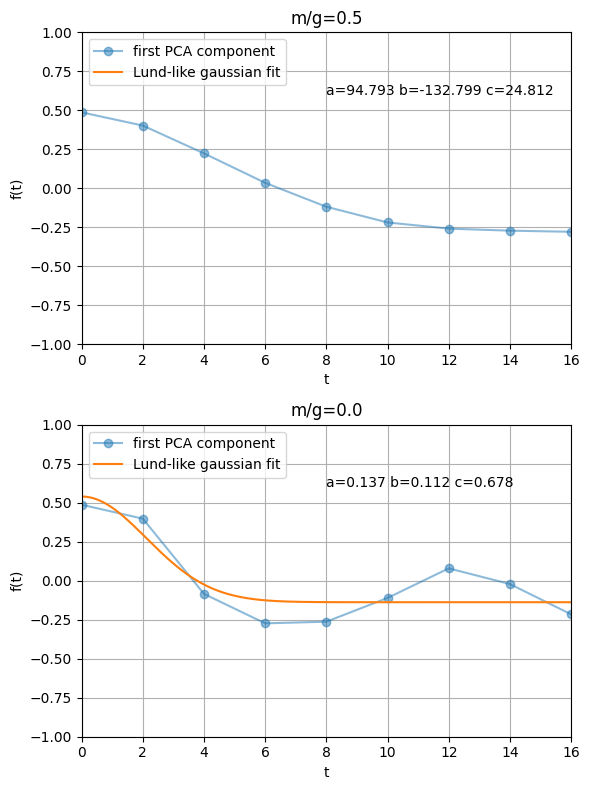

In [38]:
cm = plt.cm.jet
fig, axs = plt.subplots(len(ms), 1, squeeze=False)
fig.set_size_inches(6, len(ms) * 4)
slc = slice(None)

D = 256
for ii, m in enumerate(ms[::-1]):
  for jj, xx in enumerate([1]):
      dominant_component(axs[ii, jj], m, D)

fig.tight_layout()

In [39]:
def get_ent(m, D, normalize = False):
    tmp = np.zeros((len(ts), len(LLs)))
    for i, t in enumerate(ts):
        for j, x in enumerate(PRs[m, D, t]):
           v = x['SL']['data']
           if normalize:
               v = v / np.sqrt(sum(v ** 2))
           tmp[i, j] = -2 * sum(v * v * np.log2(v))
    return tmp

In [46]:
def get_sv(m, D, normalize = False, num=4):
    tmp = np.zeros((len(ts), 256))
    for i, t in enumerate(ts):
        v = PRs[m, D, t][num]['SL']['data']
        lv = min(len(v), 256)
        if normalize:
            v = v / np.sqrt(sum(v ** 2))
        tmp[i, :lv] = v[:lv]
    return tmp

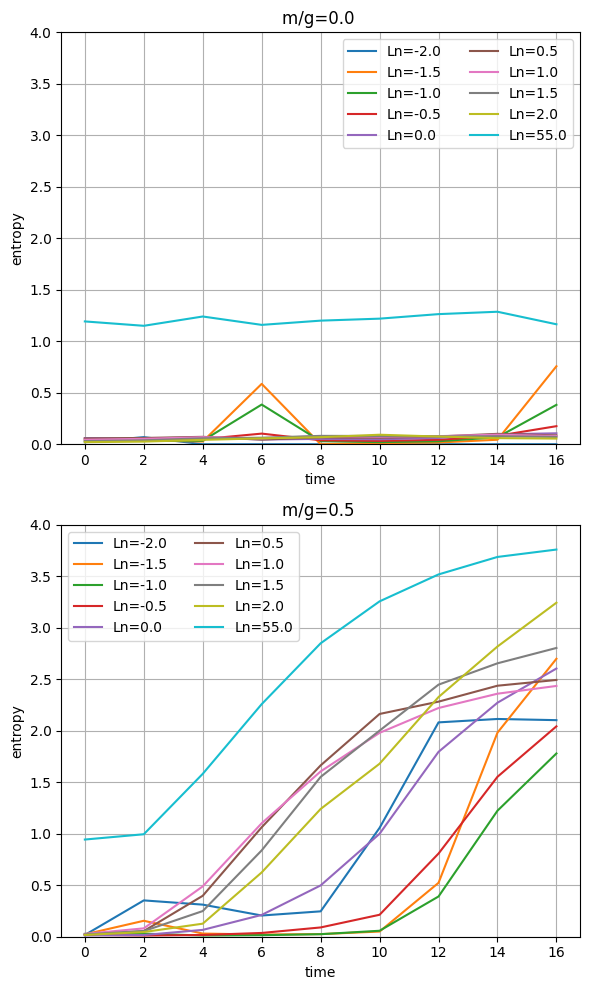

In [47]:
cm = plt.cm.jet
PPs = np.linspace(0, 6, 49)


D = 256
m = 0.5
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(ms), len([1]), squeeze=False)
fig.set_size_inches(len([1]) * 6, len(ms) * 5)
for ii, m in enumerate(ms):
  for jj, xx in enumerate([1]):
      tmp = get_ent(m, D, normalize=True)
      for kk, l in enumerate(LLs):
        axs[ii,jj].plot(ts[slc], tmp[slc, kk], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 4)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('entropy')
      axs[ii,jj].set_title(f"{m/g=} ")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


/tmp/ipykernel_63345/1621395890.py:12: RuntimeWarning: divide by zero encountered in log2
  axs[ii,jj].plot(ts, -np.log2(tmp), '-+', color='r')
/tmp/ipykernel_63345/1621395890.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[ii,jj].legend(ncols=2)


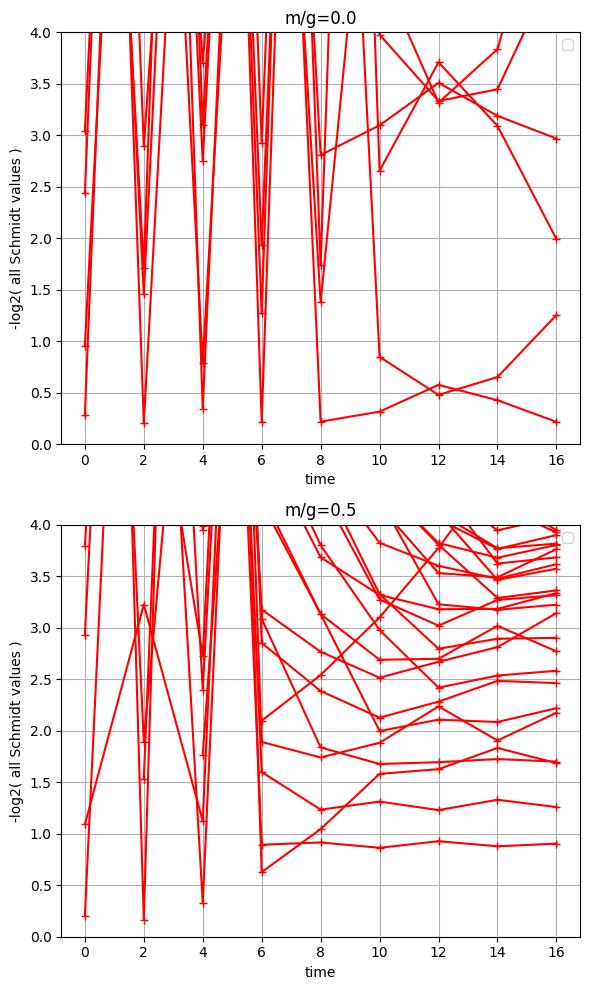

In [59]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]

D = 256
slc = slice(None)
fig, axs = plt.subplots(len(ms), len([1]), squeeze=False)
fig.set_size_inches(len([1]) * 6, len(ms) * 5)

for ii, m in enumerate(ms):
  for jj, xx in enumerate([1]):
      tmp = get_sv(m, D, normalize=False, num=9)
      axs[ii,jj].plot(ts, -np.log2(tmp), '-+', color='r')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 4)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('-log2( all Schmidt values )')
      axs[ii,jj].set_title(f"{m/g=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [ ]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]

sg2x0s = [(0.25, 1.5), (0.0625, 1.5), (0.25, 3.0), (0.0625, 3.0)]
Ps = [0, 1, 2, 3, 4]

D = 256
m = 0.0
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(sg2x0s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(sg2x0s) * 5)
for ii, (sg2, x0) in enumerate(sg2x0s):
  for jj, PP in enumerate(Ps):

      tmp = get_ent(x0, sg2, m, PP, D)
      for kk, l in enumerate(LLs):
        axs[ii,jj].plot(ts[slc], tmp[slc, kk], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 3)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('probability')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [ ]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]

D = 256
slc = slice(None)
fig, axs = plt.subplots(len(ms), len([1]), squeeze=False)
fig.set_size_inches(len([1]) * 6, len(ms) * 5)

for ii, m in enumerate(ms):
  for jj, xx in enumerate([1]):
      tmp = get_sv(m, D, normalize=True, num=6)
      axs[ii,jj].plot(ts, -np.log2(tmp), '-+', color='c')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 4)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('-log2(Schmidt values with Ln=0)')
      axs[ii,jj].set_title(f"{m/g=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()
